# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder
from implicit.als import AlternatingLeastSquares
from scipy.sparse import coo_matrix
import numpy as np
import gc

/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [3]:
tracks = pd.read_parquet("data/tracks.parquet")
catalog_names = pd.read_parquet("data/catalog_names.parquet")
interactions = pd.read_parquet("data/interactions.parquet")

print("tracks:", tracks.shape)
print("catalog_names:", catalog_names.shape)
print("interactions:", interactions.shape)

display(tracks.head())
display(catalog_names.head())
display(interactions.head())

tracks: (1000000, 4)
catalog_names: (1812471, 3)
interactions: (222629898, 4)


,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


In [4]:
interactions.info()
print()
tracks.info()
print()
catalog_names.info()


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), ob

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
print("Треков без исполнителей:", tracks["artists"].apply(len).eq(0).sum())
print("Треков без альбомов:", tracks["albums"].apply(len).eq(0).sum())
print("Треков без жанров:", tracks["genres"].apply(len).eq(0).sum())

Треков без исполнителей: 15369
Треков без альбомов: 18
Треков без жанров: 3687


In [6]:
total_tracks = len(tracks)

no_artists_pct = tracks["artists"].apply(len).eq(0).mean() * 100
no_albums_pct = tracks["albums"].apply(len).eq(0).mean() * 100
no_genres_pct = tracks["genres"].apply(len).eq(0).mean() * 100

print(f"Треков без исполнителей: {no_artists_pct:.3f}%")
print(f"Треков без альбомов: {no_albums_pct:.3f}%")
print(f"Треков без жанров: {no_genres_pct:.3f}%")

Треков без исполнителей: 1.537%
Треков без альбомов: 0.002%
Треков без жанров: 0.369%


In [7]:
known_ids = set(catalog_names["id"])

all_artist_ids = set(tracks["artists"].explode().dropna())
all_album_ids = set(tracks["albums"].explode().dropna())
all_genre_ids = set(tracks["genres"].explode().dropna())

print("Неизвестных исполнителей:", len(all_artist_ids - known_ids))
print("Неизвестных альбомов:", len(all_album_ids - known_ids))
print("Неизвестных жанров:", len(all_genre_ids - known_ids))

Неизвестных исполнителей: 0
Неизвестных альбомов: 0
Неизвестных жанров: 11


In [8]:
missing_genre_ids = all_genre_ids - known_ids
print(missing_genre_ids)

affected_tracks = tracks[tracks["genres"].apply(lambda g: any(x in missing_genre_ids for x in g))]
print("Треков, где встречается хотя бы один неизвестный жанр:", len(affected_tracks))
print("Доля от общего числа треков:", round(len(affected_tracks) / len(tracks) * 100, 2), "%")

{160, 161, 130, 131, 164, 168, 169, 153, 155, 124, 159}
Треков, где встречается хотя бы один неизвестный жанр: 18323
Доля от общего числа треков: 1.83 %


In [9]:
print(tracks.isna().sum())
print(interactions.isna().sum())
print("Дубликаты track_id в tracks:", tracks["track_id"].duplicated().sum())

track_id    0
albums      0
artists     0
genres      0
dtype: int64
user_id       0
track_id      0
track_seq     0
started_at    0
dtype: int64
Дубликаты track_id в tracks: 0


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

## Почему важно найти аномалии?
"Холодные" треки невозможно сопоставить в случае контентного подхода, но удалять их все же не стоит:
если их всё же оставить в датасете, то они могут быть валидными кандидатами для ALS/коллаборативной фильтрации.

Тем более "холодных" данных у нас немного: 
* Треков без исполнителей: 1.537%
* Треков без альбомов: 0.002%
* Треков без жанров: 0.369%

Для неизвестных жанров лучше всего создать отдельный класс 'unknown_genre', так как их довольно много:
* Треков, где встречается хотя бы один неизвестный жанр: 18323
* Доля от общего числа треков: 1.83 %

In [10]:
catalog_names_genres = catalog_names[catalog_names["type"] == "genre"].copy()

unknown_genre_stub = pd.DataFrame({
    "id": list(missing_genre_ids),
    "type": "genre",
    "name": "Unknown"
})
catalog_names_genres = pd.concat([catalog_names_genres, unknown_genre_stub], ignore_index=True)

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

count    1.373221e+06
mean     1.621224e+02
std      3.512846e+02
min      1.000000e+00
25%      2.300000e+01
50%      5.500000e+01
75%      1.540000e+02
max      1.663700e+04
dtype: float64


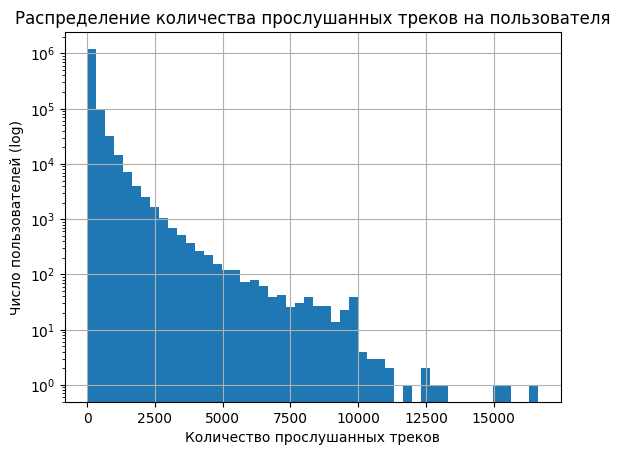

In [11]:
tracks_per_user = interactions.groupby("user_id").size()

print(tracks_per_user.describe())

tracks_per_user.hist(bins=50, log=True)
plt.xlabel("Количество прослушанных треков")
plt.ylabel("Число пользователей (log)")
plt.title("Распределение количества прослушанных треков на пользователя")
plt.show()

Наиболее популярные треки

In [12]:
top_tracks = interactions["track_id"].value_counts().head(20)

top_tracks_named = top_tracks.rename("play_count").reset_index().rename(columns={"index": "track_id"})
top_tracks_named = top_tracks_named.merge(
    catalog_names[catalog_names["type"] == "track"][["id", "name"]],
    left_on="track_id", right_on="id", how="left"
)
print(top_tracks_named[["track_id", "name", "play_count"]])

    track_id                     name  play_count
0      53404  Smells Like Teen Spirit      111062
1   33311009                 Believer      106921
2     178529                     Numb      101924
3   35505245               I Got Love       99490
4   65851540                   Юность       86670
5   24692821           Way Down We Go       86246
6   32947997             Shape of You       85886
7   51241318               In The End       85244
8     795836        Shape Of My Heart       85042
9   45499814                     Life       84748
10  60292250          Blinding Lights       84471
11   6705392        Seven Nation Army       82483
12  39257277               In My Mind       81978
13  29544272                    Human       81057
14     37384                   Zombie       80153
15  51516485                  bad guy       78370
16   2758009      The Show Must Go On       78181
17  47627256                  Cradles       76052
18    328683         Bring Me To Life       75686


Наиболее популярные жанры

In [13]:
# 1. Считаем прослушивания на трек — компактная таблица
track_play_counts = interactions["track_id"].value_counts().rename("play_count").reset_index()
track_play_counts = track_play_counts.rename(columns={"index": "track_id"})

# 2. Берём только жанры для треков, у которых были прослушивания
track_genres = tracks.loc[tracks["track_id"].isin(track_play_counts["track_id"]), ["track_id", "genres"]]
track_genres = track_genres.explode("genres").rename(columns={"genres": "genre_id"})

# 3. Мёржим компактные таблицы между собой (а не с полным interactions)
genre_play_counts = track_genres.merge(track_play_counts, on="track_id", how="left")

# 4. Группируем по жанру и суммируем прослушивания
top_genres = (
    genre_play_counts.groupby("genre_id")["play_count"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)

# 5. Добавляем названия
top_genres_named = top_genres.merge(
    catalog_names[catalog_names["type"] == "genre"][["id", "name"]],
    left_on="genre_id", right_on="id", how="left"
)

print(top_genres_named[["genre_id", "name", "play_count"]])

    genre_id         name  play_count
0         11          pop    55578312
1         75          rap    37799821
2        102      allrock    31092013
3         20       ruspop    26626241
4          3       rusrap    25303695
5         68  electronics    20120981
6         16        dance    16291557
7          2      rusrock    13166147
8         14         rock    12772644
9         47        metal    12437375
10        44   foreignrap    12194657
11        13  alternative    10111562
12        70        indie     9993671
13       325      estrada     6896593
14        25   soundtrack     5910628
15        19   rusestrada     4960458
16         6  local-indie     4068270
17        21         folk     3969678
18        50         punk     3768826
19        74          rnb     3287311


Треки, которые никто не прослушал

In [14]:
listened_track_ids = set(interactions["track_id"].unique())
all_track_ids = set(tracks["track_id"].unique())

never_listened = all_track_ids - listened_track_ids
print(f"Треков без прослушиваний: {len(never_listened)}")
print(f"Доля от общего числа треков: {len(never_listened) / len(all_track_ids) * 100:.2f}%")

Треков без прослушиваний: 0
Доля от общего числа треков: 0.00%


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [15]:
# приводим идентификаторы к более компактному типу
tracks["track_id"] = tracks["track_id"].astype("int32")
interactions["user_id"] = interactions["user_id"].astype("int32")
interactions["track_id"] = interactions["track_id"].astype("int32")
catalog_names["id"] = catalog_names["id"].astype("int32")

# заполняем пустые списки явной категорией "unknown", чтобы не терять информацию
UNKNOWN_ID = -1
tracks["artists"] = tracks["artists"].apply(lambda x: x if len(x) > 0 else [UNKNOWN_ID])
tracks["albums"] = tracks["albums"].apply(lambda x: x if len(x) > 0 else [UNKNOWN_ID])
tracks["genres"] = tracks["genres"].apply(lambda x: x if len(x) > 0 else [UNKNOWN_ID])

unknown_row = pd.DataFrame({"id": [UNKNOWN_ID], "type": ["unknown"], "name": ["Unknown"]})
catalog_names = pd.concat([catalog_names, unknown_row], ignore_index=True)

# приводим started_at к datetime, если он изначально хранится не в этом формате
interactions["started_at"] = pd.to_datetime(interactions["started_at"])

# финализируем items и events
items = tracks.copy()
events = interactions.copy()

print(items.shape, events.shape)
print(items.dtypes)
print(events.dtypes)

(1000000, 4) (222629898, 4)
track_id     int32
albums      object
artists     object
genres      object
dtype: object
user_id                int32
track_id               int32
track_seq              int16
started_at    datetime64[ns]
dtype: object


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [16]:
bucket_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/data/"

os.environ["AWS_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

storage_options = {
    "client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"}
}

items.to_parquet(bucket_path + "items.parquet", storage_options=storage_options)
events.to_parquet(bucket_path + "events.parquet", storage_options=storage_options)

print("Файлы сохранены")

Файлы сохранены


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [17]:
import gc

# удаляем большие промежуточные объекты, которые больше не нужны:
# items и events уже сохранены в S3
del tracks, interactions, catalog_names
del items, events
del track_genres
del top_genres, top_genres_named, top_tracks, top_tracks_named
del tracks_per_user

gc.collect()

print("Память очищена")

Память очищена


# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [18]:
os.environ["AWS_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
storage_options = {"client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"}}

bucket_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/data/"

items = pd.read_parquet(bucket_path + "items.parquet", storage_options=storage_options)
events = pd.read_parquet(bucket_path + "events.parquet", storage_options=storage_options)

print(items.shape, events.shape)

(1000000, 4) (222629898, 4)


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [19]:
split_date = pd.to_datetime("2022-12-16").date()

events["started_at"] = pd.to_datetime(events["started_at"])
train_idx = events["started_at"].dt.date < split_date

events_train = events[train_idx].copy()
events_test = events[~train_idx].copy()

print("train:", events_train.shape, "test:", events_test.shape)

train: (208731252, 4) test: (13898646, 4)


In [20]:
sample_frac = 0.05  # 5% пользователей 

all_users = events_train["user_id"].unique()
np.random.seed(0)
sample_users = np.random.choice(all_users, size=int(len(all_users) * sample_frac), replace=False)

events_train_full = events_train  # сохраняем оригинал на случай, если понадобится позже
events_train = events_train[events_train["user_id"].isin(sample_users)].copy()

print("Было:", events_train_full.shape)
print("Стало:", events_train.shape)

del events_train_full
import gc
gc.collect()

Было: (208731252, 4)
Стало: (10344688, 4)


13

In [21]:
events_test_full = events_test
events_test = events_test[events_test["user_id"].isin(sample_users)].copy()

print("Test было:", events_test_full.shape)
print("Test стало:", events_test.shape)

del events_test_full
gc.collect()

Test было: (13898646, 4)
Test стало: (637504, 4)


0

In [22]:
events_train["user_id_enc"], user_uniques = pd.factorize(events_train["user_id"])
events_train["track_id_enc"], item_uniques = pd.factorize(events_train["track_id"])

events_train["user_id_enc"] = events_train["user_id_enc"].astype("int32")
events_train["track_id_enc"] = events_train["track_id_enc"].astype("int32")

n_users = len(user_uniques)
n_items = len(item_uniques)
print(n_users, n_items)

67128 615660


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [23]:
top_popular = (
    events_train["track_id"].value_counts().reset_index()
)

top_popular.columns = ["track_id", "play_count"]
top_popular["rank"] = range(1, len(top_popular) + 1)
top_popular = top_popular.head(100)

rec_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/"
top_popular.to_parquet(rec_path + "top_popular.parquet", storage_options=storage_options)
print(top_popular.head())

   track_id  play_count  rank
0     53404        5453     1
1    178529        4997     2
2  33311009        4984     3
3  35505245        4771     4
4  24692821        4099     5


# Персональные

Рассчитаем персональные рекомендации.

In [24]:
user_idx = events_train["user_id_enc"].to_numpy()
item_idx = events_train["track_id_enc"].to_numpy()
data = np.ones(len(events_train), dtype=np.float32)

train_matrix = coo_matrix((data, (user_idx, item_idx)), shape=(n_users, n_items)).tocsr()

del user_idx, item_idx, data
gc.collect()

5

In [25]:
als_model = AlternatingLeastSquares(
    factors=16,
    iterations=10,
    regularization=0.05,
    random_state=0,
    num_threads=1
)
als_model.fit(train_matrix)

/home/mle-user/mle_projects/mle-project-sprint-4-v001/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [00:35<00:00,  3.53s/it]


In [26]:
test_users_enc = np.arange(n_users)

als_ids, als_scores = als_model.recommend(
    test_users_enc,
    train_matrix[test_users_enc],
    N=100,
    filter_already_liked_items=True
)

In [27]:
# Собрать в DataFrame и развернуть списки в строки
personal_als = pd.DataFrame({
    "user_id_enc": test_users_enc,
    "track_id_enc": als_ids.tolist(),
    "score": als_scores.tolist()
})
personal_als = personal_als.explode(["track_id_enc", "score"])

In [28]:
personal_als["track_id_enc"] = personal_als["track_id_enc"].astype("int32")
personal_als["score"] = personal_als["score"].astype("float32")

personal_als["user_id"] = user_uniques[personal_als["user_id_enc"].to_numpy()]
personal_als["track_id"] = item_uniques[personal_als["track_id_enc"].to_numpy()]
personal_als = personal_als.drop(columns=["user_id_enc", "track_id_enc"])

In [29]:
personal_als = personal_als.sort_values(["user_id", "score"], ascending=[True, False])
personal_als["rank"] = personal_als.groupby("user_id").cumcount() + 1

In [30]:
os.environ["AWS_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
storage_options = {"client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"}}

rec_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/"

personal_als.to_parquet(rec_path + "personal_als.parquet", storage_options=storage_options)

print("Файл сохранён:", rec_path + "personal_als.parquet")

Файл сохранён: s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/personal_als.parquet


# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [31]:
max_similar = 10

min_interactions = 5
item_counts = events_train["track_id_enc"].value_counts()
frequent_items = item_counts[item_counts >= min_interactions].index.to_numpy()

print(f"Треков для similar_items: {len(frequent_items)} из {n_items}")

sim_ids, sim_scores = als_model.similar_items(frequent_items, N=max_similar + 1)

Треков для similar_items: 206458 из 615660


In [32]:
similar = pd.DataFrame({
    "track_id_enc": frequent_items,
    "sim_track_id_enc": sim_ids.tolist(),
    "score": sim_scores.tolist()
})
similar = similar.explode(["sim_track_id_enc", "score"])

similar["sim_track_id_enc"] = similar["sim_track_id_enc"].astype("int32")
similar["score"] = similar["score"].astype("float32")

similar["track_id_1"] = item_uniques[similar["track_id_enc"].to_numpy()]
similar["track_id_2"] = item_uniques[similar["sim_track_id_enc"].to_numpy()]
similar = similar.drop(columns=["track_id_enc", "sim_track_id_enc"])

similar = similar.query("track_id_1 != track_id_2")

similar = similar.sort_values(["track_id_1", "score"], ascending=[True, False])

In [33]:
os.environ["AWS_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
storage_options = {"client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"}}

rec_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/"

similar.to_parquet(rec_path + "similar.parquet", storage_options=storage_options)

print("Файл сохранён:", rec_path + "similar.parquet")
print(similar.shape)
print(similar.head())

Файл сохранён: s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/similar.parquet
(2064638, 3)
          score  track_id_1  track_id_2
71722  0.957613         141     9407354
71722  0.949793         141    44100843
71722  0.948529         141      145443
71722  0.946483         141    30918132
71722  0.943811         141      358795


# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

## Похожесть жанров пользователя и трека

In [34]:
# явно заполняем пустые жанры как "unknown" (используем UNKNOWN_ID, если применялось на этапе preprocessing)
genre_columns_source = items[["track_id", "genres"]].explode("genres").rename(columns={"genres": "genre_id"})

# считаем распределение жанров, которые слушал каждый пользователь
user_genre_history = events_train.merge(genre_columns_source, on="track_id", how="left")
user_genre_counts = (
    user_genre_history
    .groupby(["user_id", "genre_id"])
    .size()
    .reset_index(name="count")
)
# нормализуем — доля каждого жанра в истории пользователя
user_genre_totals = user_genre_counts.groupby("user_id")["count"].transform("sum")
user_genre_counts["genre_share"] = user_genre_counts["count"] / user_genre_totals

def compute_genre_match(candidates, items, user_genre_counts):
    cand_genres = candidates[["user_id", "track_id"]].merge(
        items[["track_id", "genres"]], on="track_id", how="left"
    )
    cand_genres = cand_genres.explode("genres").rename(columns={"genres": "genre_id"})
    
    cand_genres = cand_genres.merge(
        user_genre_counts[["user_id", "genre_id", "genre_share"]],
        on=["user_id", "genre_id"], how="left"
    )
    cand_genres["genre_share"] = cand_genres["genre_share"].fillna(0)
    
    genre_match = cand_genres.groupby(["user_id", "track_id"])["genre_share"].mean().reset_index()
    genre_match = genre_match.rename(columns={"genre_share": "genre_match_score"})
    return genre_match

## Известность артиста пользователю (бинарный признак)

In [35]:
user_artist_history = events_train.merge(items[["track_id", "artists"]], on="track_id", how="left")
user_artist_history = user_artist_history.explode("artists").rename(columns={"artists": "artist_id"})
user_known_artists = user_artist_history.groupby("user_id")["artist_id"].apply(set).rename("known_artists")

def compute_artist_known(candidates, items, user_known_artists):
    cand_artists = candidates[["user_id", "track_id"]].merge(
        items[["track_id", "artists"]], on="track_id", how="left"
    )
    cand_artists = cand_artists.merge(user_known_artists, on="user_id", how="left")

    def check_known(row):
        if not isinstance(row["known_artists"], set):
            return 0
        return int(any(a in row["known_artists"] for a in row["artists"]))

    cand_artists["artist_known"] = cand_artists.apply(check_known, axis=1)
    return cand_artists[["user_id", "track_id", "artist_known"]]

## Play count трека (популярность)

In [36]:
track_play_counts = events_train["track_id"].value_counts().rename("play_count").reset_index()
track_play_counts.columns = ["track_id", "play_count"]

## Train

In [37]:
candidates_for_train = personal_als[["user_id", "track_id", "score"]].rename(columns={"score": "als_score"})

# добавляем target (был ли трек реально прослушан пользователем в events_test)
events_test_labels = events_test[["user_id", "track_id"]].drop_duplicates()
events_test_labels["target"] = 1

candidates_for_train = candidates_for_train.merge(
    events_test_labels, on=["user_id", "track_id"], how="left"
)
candidates_for_train["target"] = candidates_for_train["target"].fillna(0).astype("int")

# добавляем 4 признака
genre_match = compute_genre_match(candidates_for_train, items, user_genre_counts)
candidates_for_train = candidates_for_train.merge(genre_match, on=["user_id", "track_id"], how="left")

artist_known = compute_artist_known(candidates_for_train, items, user_known_artists)
candidates_for_train = candidates_for_train.merge(artist_known, on=["user_id", "track_id"], how="left")

candidates_for_train = candidates_for_train.merge(track_play_counts, on="track_id", how="left")
candidates_for_train["play_count"] = candidates_for_train["play_count"].fillna(0)

print(candidates_for_train.shape)
print(candidates_for_train.head())

(6712800, 7)
   user_id  track_id  als_score  target  genre_match_score  artist_known  \
0        7  49961817   0.022010       0           0.072289             1   
1        7  65851540   0.021963       0           0.072289             0   
2        7  52380688   0.021593       0           0.072289             0   
3        7  57921154   0.019800       0           0.072289             0   
4        7  45499814   0.019023       0           0.072289             0   

   play_count  
0        3523  
1        3882  
2        3313  
3        3450  
4        3942  


## Test

In [38]:
# кандидаты для ранжирования — берём personal_als (топ-100 на пользователя)
candidates_to_rank = personal_als[["user_id", "track_id", "score"]].rename(columns={"score": "als_score"})

# считаем те же признаки, что и для train, но user-историю строим из events_train
# (чтобы не было утечки данных из будущего — test не должен участвовать в подсчёте истории)
genre_match_rank = compute_genre_match(candidates_to_rank, items, user_genre_counts)
candidates_to_rank = candidates_to_rank.merge(genre_match_rank, on=["user_id", "track_id"], how="left")

artist_known_rank = compute_artist_known(candidates_to_rank, items, user_known_artists)
candidates_to_rank = candidates_to_rank.merge(artist_known_rank, on=["user_id", "track_id"], how="left")

candidates_to_rank = candidates_to_rank.merge(track_play_counts, on="track_id", how="left")
candidates_to_rank["play_count"] = candidates_to_rank["play_count"].fillna(0)

print(candidates_to_rank.shape)
print(candidates_to_rank.head())

(6712800, 6)
   user_id  track_id  als_score  genre_match_score  artist_known  play_count
0        7  49961817   0.022010           0.072289             1        3523
1        7  65851540   0.021963           0.072289             0        3882
2        7  52380688   0.021593           0.072289             0        3313
3        7  57921154   0.019800           0.072289             0        3450
4        7  45499814   0.019023           0.072289             0        3942


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [39]:
from catboost import CatBoostClassifier, Pool

# задаём имена колонок признаков и таргета
features = ['als_score', 'genre_match_score', 'artist_known', 'play_count']
target = 'target'

# создаём Pool
train_data = Pool(
    data=candidates_for_train[features], 
    label=candidates_for_train[target])

# инициализируем модель CatBoostClassifier
cb_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100,
    random_seed=0,
)

# тренируем модель
cb_model.fit(train_data)

0:	learn: 0.4502022	total: 672ms	remaining: 5m 35s
100:	learn: 0.0241477	total: 51.7s	remaining: 3m 24s
200:	learn: 0.0239139	total: 1m 44s	remaining: 2m 36s
300:	learn: 0.0237795	total: 2m 38s	remaining: 1m 44s
400:	learn: 0.0236664	total: 3m 32s	remaining: 52.4s
499:	learn: 0.0235453	total: 4m 25s	remaining: 0us


In [40]:
inference_data = Pool(data=candidates_to_rank[features])
predictions = cb_model.predict_proba(inference_data)
print("predict_proba завершён:", predictions.shape)

predict_proba завершён: (6712800, 2)


In [41]:
del inference_data
import gc
gc.collect()

candidates_to_rank["cb_score"] = predictions[:, 1].astype("float32")
del predictions
gc.collect()

print(candidates_to_rank.shape)

(6712800, 7)


In [42]:
candidates_to_rank = candidates_to_rank.sort_values(["user_id", "cb_score"], ascending=[True, False])
candidates_to_rank["rank"] = candidates_to_rank.groupby("user_id").cumcount() + 1
print("Сортировка и ранжирование завершены")

Сортировка и ранжирование завершены


In [43]:
max_recommendations_per_user = 100
recommendations = candidates_to_rank[candidates_to_rank["rank"] <= max_recommendations_per_user].copy()

print(recommendations.shape)
print(recommendations.head())

(6712800, 8)
    user_id  track_id  als_score  genre_match_score  artist_known  play_count  \
6         7  66869588   0.018622           0.072289             0        2226   
73        7  84382282   0.008427           0.060241             0        2230   
78        7  62352386   0.008269           0.072289             1         937   
27        7  62352385   0.012506           0.072289             1        1455   
1         7  65851540   0.021963           0.072289             0        3882   

    cb_score  rank  
6   0.008588     1  
73  0.005566     2  
78  0.005410     3  
27  0.005390     4  
1   0.005234     5  


In [44]:
os.environ["AWS_ENDPOINT_URL"] = "https://storage.yandexcloud.net"
storage_options = {"client_kwargs": {"endpoint_url": "https://storage.yandexcloud.net"}}

rec_path = "s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/"

recommendations.to_parquet(rec_path + "recommendations.parquet", storage_options=storage_options)

print("Файл сохранён:", rec_path + "recommendations.parquet")
print(recommendations.shape)
print(recommendations.head())

Файл сохранён: s3://s3-student-mle-20260512-e5accb6525-freetrack/recsys/recommendations/recommendations.parquet
(6712800, 8)
    user_id  track_id  als_score  genre_match_score  artist_known  play_count  \
6         7  66869588   0.018622           0.072289             0        2226   
73        7  84382282   0.008427           0.060241             0        2230   
78        7  62352386   0.008269           0.072289             1         937   
27        7  62352385   0.012506           0.072289             1        1455   
1         7  65851540   0.021963           0.072289             0        3882   

    cb_score  rank  
6   0.008588     1  
73  0.005566     2  
78  0.005410     3  
27  0.005390     4  
1   0.005234     5  


# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [47]:
def process_events_recs_for_binary_metrics(events_train, events_test, recs, top_k=None):
    events_test = events_test.copy()
    events_test["gt"] = True
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    events_for_common = events_test[events_test["user_id"].isin(common_users)].copy()
    recs_for_common = recs[recs["user_id"].isin(common_users)].copy()

    recs_for_common = recs_for_common.sort_values(["user_id", "score"], ascending=[True, False])

    events_for_common = events_for_common[events_for_common["track_id"].isin(events_train["track_id"].unique())]

    if top_k is not None:
        recs_for_common = recs_for_common.groupby("user_id").head(top_k)

    merged = events_for_common[["user_id", "track_id", "gt"]].merge(
        recs_for_common[["user_id", "track_id", "score"]],
        on=["user_id", "track_id"], how="outer"
    )
    merged["gt"] = merged["gt"].fillna(False)
    merged["pr"] = ~merged["score"].isnull()

    merged["tp"] = merged["gt"] & merged["pr"]
    merged["fp"] = ~merged["gt"] & merged["pr"]
    merged["fn"] = merged["gt"] & ~merged["pr"]

    return merged


def compute_cls_metrics(df):
    tp = df["tp"].sum()
    fp = df["fp"].sum()
    fn = df["fn"].sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return precision, recall


def compute_coverage(recs, all_items):
    recommended_items = set(recs["track_id"].unique())
    return len(recommended_items) / len(all_items)


def compute_novelty(recs, track_play_counts, total_interactions):
    # убираем play_count из recs, если он там уже есть, чтобы избежать конфликта имён при merge
    # novelty = средний -log2(популярность трека) — чем реже трек, тем выше новизна
    recs_clean = recs.drop(columns=["play_count"], errors="ignore")
    merged = recs_clean.merge(track_play_counts, on="track_id", how="left")
    merged["play_count"] = merged["play_count"].fillna(1)
    merged["item_novelty"] = -np.log2(merged["play_count"] / total_interactions)
    return merged["item_novelty"].mean()

In [48]:
all_items = items["track_id"].unique()
total_interactions = len(events_train)

# --- 1. Топ популярных ---
top_popular_scored = top_popular.rename(columns={"play_count": "score"})
top_popular_scored["user_id"] = -1  # заглушка, т.к. top_popular не персонален

# для метрик recall/precision присвоим одни и те же топ-рекомендации каждому пользователю из теста
test_users = events_test["user_id"].unique()
top_popular_expanded = pd.DataFrame({
    "user_id": np.repeat(test_users, len(top_popular)),
    "track_id": np.tile(top_popular["track_id"].values, len(test_users)),
    "score": np.tile(top_popular["play_count"].values, len(test_users))
})

metrics_df_top = process_events_recs_for_binary_metrics(events_train, events_test, top_popular_expanded, top_k=100)
precision_top, recall_top = compute_cls_metrics(metrics_df_top)
coverage_top = compute_coverage(top_popular, all_items)
novelty_top = compute_novelty(top_popular, track_play_counts, total_interactions)

print(f"Top Popular — precision: {precision_top:.4f}, recall: {recall_top:.4f}, coverage: {coverage_top:.4f}, novelty: {novelty_top:.4f}")

# --- 2. Персональные (ALS) ---
personal_als_scored = personal_als.rename(columns={"score": "score"})
metrics_df_als = process_events_recs_for_binary_metrics(events_train, events_test, personal_als_scored, top_k=100)
precision_als, recall_als = compute_cls_metrics(metrics_df_als)
coverage_als = compute_coverage(personal_als, all_items)
novelty_als = compute_novelty(personal_als, track_play_counts, total_interactions)

print(f"Personal ALS — precision: {precision_als:.4f}, recall: {recall_als:.4f}, coverage: {coverage_als:.4f}, novelty: {novelty_als:.4f}")

# --- 3. Итоговые (ранжированные CatBoost) ---
recommendations_scored = recommendations.rename(columns={"cb_score": "score"})
metrics_df_final = process_events_recs_for_binary_metrics(events_train, events_test, recommendations_scored, top_k=100)
precision_final, recall_final = compute_cls_metrics(metrics_df_final)
coverage_final = compute_coverage(recommendations, all_items)
novelty_final = compute_novelty(recommendations, track_play_counts, total_interactions)

print(f"Final (ranked) — precision: {precision_final:.4f}, recall: {recall_final:.4f}, coverage: {coverage_final:.4f}, novelty: {novelty_final:.4f}")

Top Popular — precision: 0.0038, recall: 0.0232, coverage: 0.0001, novelty: 11.7508
Personal ALS — precision: 0.0069, recall: 0.0424, coverage: 0.0041, novelty: 12.6851
Final (ranked) — precision: 0.0069, recall: 0.0424, coverage: 0.0041, novelty: 12.6851


In [49]:
def compute_ndcg(events_train, events_test, recs, k=10):
    """
    NDCG@k — учитывает не только какие треки порекомендованы,
    но и на каком месте оказался релевантный трек (чем выше, тем лучше).
    Бинарная релевантность: 1, если пользователь реально прослушал трек в тесте.
    """
    common_users = set(events_test["user_id"]) & set(recs["user_id"])

    events_for_common = events_test[events_test["user_id"].isin(common_users)]
    recs_for_common = recs[recs["user_id"].isin(common_users)].copy()

    # убираем "холодные" треки, которых не было в train
    events_for_common = events_for_common[events_for_common["track_id"].isin(events_train["track_id"].unique())]

    # для каждого пользователя — множество реально прослушанных треков (ground truth)
    gt_per_user = events_for_common.groupby("user_id")["track_id"].apply(set)

    # сортируем рекомендации по score и берём top-k
    recs_for_common = recs_for_common.sort_values(["user_id", "score"], ascending=[True, False])
    recs_for_common = recs_for_common.groupby("user_id").head(k)

    ndcg_scores = []
    discounts = 1.0 / np.log2(np.arange(2, k + 2))  # дисконты для позиций 1..k

    for user_id, group in recs_for_common.groupby("user_id"):
        gt_items = gt_per_user.get(user_id, set())
        if len(gt_items) == 0:
            continue

        track_ids = group["track_id"].tolist()
        relevance = np.array([1 if t in gt_items else 0 for t in track_ids])

        # DCG — с учётом фактической длины списка (может быть < k)
        dcg = np.sum(relevance * discounts[:len(relevance)])

        # IDCG — идеальный порядок: все релевантные треки сразу в начале
        ideal_relevance = np.sort(relevance)[::-1]
        idcg = np.sum(ideal_relevance * discounts[:len(ideal_relevance)])

        ndcg = dcg / idcg if idcg > 0 else 0
        ndcg_scores.append(ndcg)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0

In [50]:
ndcg_top = compute_ndcg(events_train, events_test, top_popular_expanded, k=10)
ndcg_als = compute_ndcg(events_train, events_test, personal_als_scored, k=10)
ndcg_final = compute_ndcg(events_train, events_test, recommendations_scored, k=10)

print(f"Top Popular — NDCG@10: {ndcg_top:.4f}")
print(f"Personal ALS — NDCG@10: {ndcg_als:.4f}")
print(f"Final (ranked) — NDCG@10: {ndcg_final:.4f}")

Top Popular — NDCG@10: 0.0096
Personal ALS — NDCG@10: 0.0385
Final (ranked) — NDCG@10: 0.0976


In [51]:
metrics_summary = pd.DataFrame({
    "model": ["Top Popular", "Personal ALS", "Final (ranked)"],
    "precision": [precision_top, precision_als, precision_final],
    "recall": [recall_top, recall_als, recall_final],
    "coverage": [coverage_top, coverage_als, coverage_final],
    "novelty": [novelty_top, novelty_als, novelty_final],
    "ndcg@10": [ndcg_top, ndcg_als, ndcg_final],
})
print(metrics_summary)

            model  precision    recall  coverage    novelty   ndcg@10
0     Top Popular   0.003775  0.023212  0.000100  11.750798  0.009613
1    Personal ALS   0.006901  0.042427  0.004107  12.685132  0.038488
2  Final (ranked)   0.006901  0.042427  0.004107  12.685132  0.097600


# === Выводы, метрики ===

* Персонализированные рекомендации(при помощи ALS) увеличили все метрики довольно сильно, как и ожидалось; этот метод работает лучше чем простая сортировка по популярности, так как учитывает взаимодействие пользователя с матрицей user2item. 

* В свою очередь ранжирование с помощью CatBoost не изменило метрики precision, recall, coverage & novelty, но существенно увеличило метрику ndcg@10. Что тоже ожидаемо: первые 4 метрики не зависят от порядка рекомендаций, в то время как ndcg нацелен именно на улучшение порядка.